In [1]:
# %pip install -r ../requirements.txt --quiet
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
project_root = os.path.abspath("..")
helpers_path = os.path.join(project_root, "helpers")
models_path = os.path.join(helpers_path, "models")
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)

if models_path not in sys.path:
    sys.path.insert(0, models_path)


# Import custom modules
from constants import TARGET_COLUMN, QUICK_TEST, NUM_PREDICTIONS, \
    QUICK_TEST_TRAIN_ROWS, QUICK_TEST_TEST_ROWS
from data_loader import load_station_data
print("Modules imported successfully!")

Modules imported successfully!


In [2]:
# Load all stations' data
station_data = load_station_data()
print(f"Stations available: {list(station_data.keys())}")

# Select a station
SELECTED_STATION = "Station1"  
df = station_data[SELECTED_STATION]

Loaded data from 6 stations.
Stations available: ['Station1', 'Station2', 'Station3', 'Station4', 'Station5', 'Station6']


In [3]:
from feature_engineering import (
    add_time_features, add_fourier_terms, drop_columns, normalize_features
)

train_df = df[df.index.year < 2020]
test_df = df[df.index.year == 2020]

if QUICK_TEST:
    train_df = train_df.iloc[-QUICK_TEST_TRAIN_ROWS:]
    test_df = test_df.iloc[-QUICK_TEST_TEST_ROWS:]

for func in [add_time_features]:
    train_df = func(train_df)
    test_df = func(test_df)

train_df = drop_columns(train_df, TARGET_COLUMN)
test_df = drop_columns(test_df, TARGET_COLUMN)

test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

train_df_scaled, test_df_scaled, scaler = normalize_features(train_df, test_df)

print("Final Features:", train_df_scaled.columns.tolist())


Final Features: ['Ppt', 'SWC_10', 'T_5', 'T_10', 'T_20', 'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'day_of_year_sin', 'day_of_year_cos']


In [4]:
from lstm_helpers import prepare_lstm_data, train_lstm


# Prepare LSTM Data
X_train, y_train, X_test, y_test = prepare_lstm_data(train_df_scaled, test_df_scaled, TARGET_COLUMN)
lstm_model = train_lstm(X_train, y_train, X_test, y_test)

from model_manager import save_model

save_model(lstm_model, SELECTED_STATION, "lstm")

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - loss: 0.2250 - val_loss: 0.5613 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - loss: 0.0057 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0031 - val_loss: 0.1164 - learning_rate: 0.0010
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.0022 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0018 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - loss: 0.0016 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - loss: 0.0017 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - loss: 0.0013 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - loss: 0.0014 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 10/10
29/29 ━━━━━━━━━━

LSTM model trained successfully.
Model saved at: lstm\Station1_20250130_162426.h5


'lstm\\Station1_20250130_162426.h5'

In [5]:
import numpy as np
import pandas as pd
from lstm_helpers import make_lstm_predictions

# NUM_PREDICTIONS = 336


lstm_predictions_scaled = make_lstm_predictions(lstm_model, test_df_scaled, TARGET_COLUMN,\
                                                num_predictions = NUM_PREDICTIONS)
num_preds = len(lstm_predictions_scaled)
preds_placeholder = test_df_scaled.iloc[-num_preds:].copy()
preds_placeholder[TARGET_COLUMN] = lstm_predictions_scaled.reshape(-1)
inversed_array = scaler.inverse_transform(preds_placeholder)
inversed_df = pd.DataFrame(inversed_array, columns=preds_placeholder.columns, index=preds_placeholder.index)
lstm_predictions_rescaled = inversed_df[TARGET_COLUMN].values
print(lstm_predictions_rescaled[:5])


[0.11060307 0.11080638 0.11113776 0.11137525 0.11166835]


In [6]:

from evaluation_helpers import evaluate_model
y_actual_scaled = test_df_scaled[TARGET_COLUMN].iloc[-num_preds:].copy().values.reshape(-1)
# Create placeholder for actual
actual_placeholder = test_df_scaled.iloc[-num_preds:].copy()
actual_placeholder[TARGET_COLUMN] = y_actual_scaled
inversed_actual = scaler.inverse_transform(actual_placeholder)
inversed_actual_df = pd.DataFrame(inversed_actual,
                                  columns=actual_placeholder.columns,
                                  index=actual_placeholder.index)
y_actual = inversed_actual_df[TARGET_COLUMN].values

###################################
# 10) Evaluate & Plot
###################################
evaluate_model(y_actual, lstm_predictions_rescaled, model_name="LSTM")



LSTM Evaluation:
Root Mean Squared Error (RMSE): 0.0004
Mean Absolute Error (MAE): 0.0121


(0.00035610230568101865, 0.01208408983459786)

SWC_10


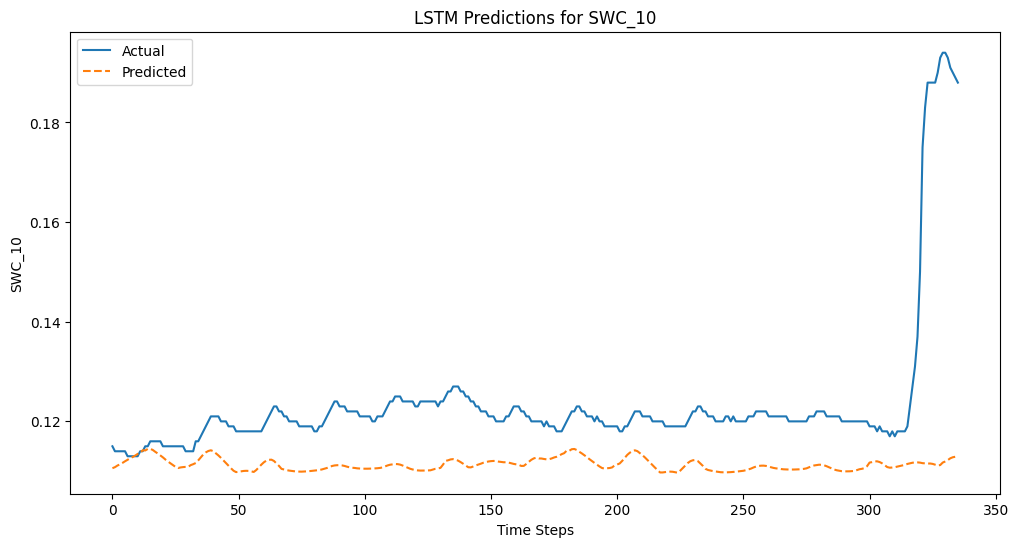

In [7]:
from plotting import plot_lstm_predictions
print(TARGET_COLUMN)
# ✅ Use rescaled predictions for plotting
plot_lstm_predictions(y_actual, lstm_predictions_rescaled, TARGET_COLUMN)
